# Rung 6 — Opening Walter up

**The question this notebook answers:** Walter predicts names well, but *how*? What are his 16 attention heads actually doing?

This is **mechanistic interpretability**: treating a trained network like an unfamiliar machine and working out its mechanisms from the inside. Knowing that a model works isn't enough. We want to know *why* it works, in terms of specific parts doing specific jobs.

We have four tools, used in the order a scientist would use them:

1. **Look**: draw the attention patterns.
2. **Measure**: summarise what every head does across thousands of names, not just one.
3. **Break**: switch heads off (**ablation**) and see what gets worse. Looking shows correlation; breaking shows causation.
4. **Read the stream**: decode the residual stream after each layer (the **logit lens**) to watch the prediction take shape.

Then we put them together to test one specific claim about one specific circuit.

In [1]:
import sys
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

sys.path.append('../rung5_gpt')
import walter_gpt as wg

names = wg.Names()
walter = wg.load_or_train(names)   # the Walter saved in Rung 5 (or retrained, same seed)
Xdev, Ydev = names.data['dev']
L, H = walter.cfg.n_layer, walter.cfg.n_head
base_loss = wg.evaluate(walter, Xdev, Ydev)
print(f'{L} layers x {H} heads = {L * H} heads to explain.  dev loss {base_loss:.4f}')

4 layers x 4 heads = 16 heads to explain.  dev loss 1.9495


## Tool 1 — Look: every head, one name

Each small square is one head reading `annabelle`. Rows are the position Walter is predicting from, and columns are the earlier positions he can look at. Dark means heavy attention.

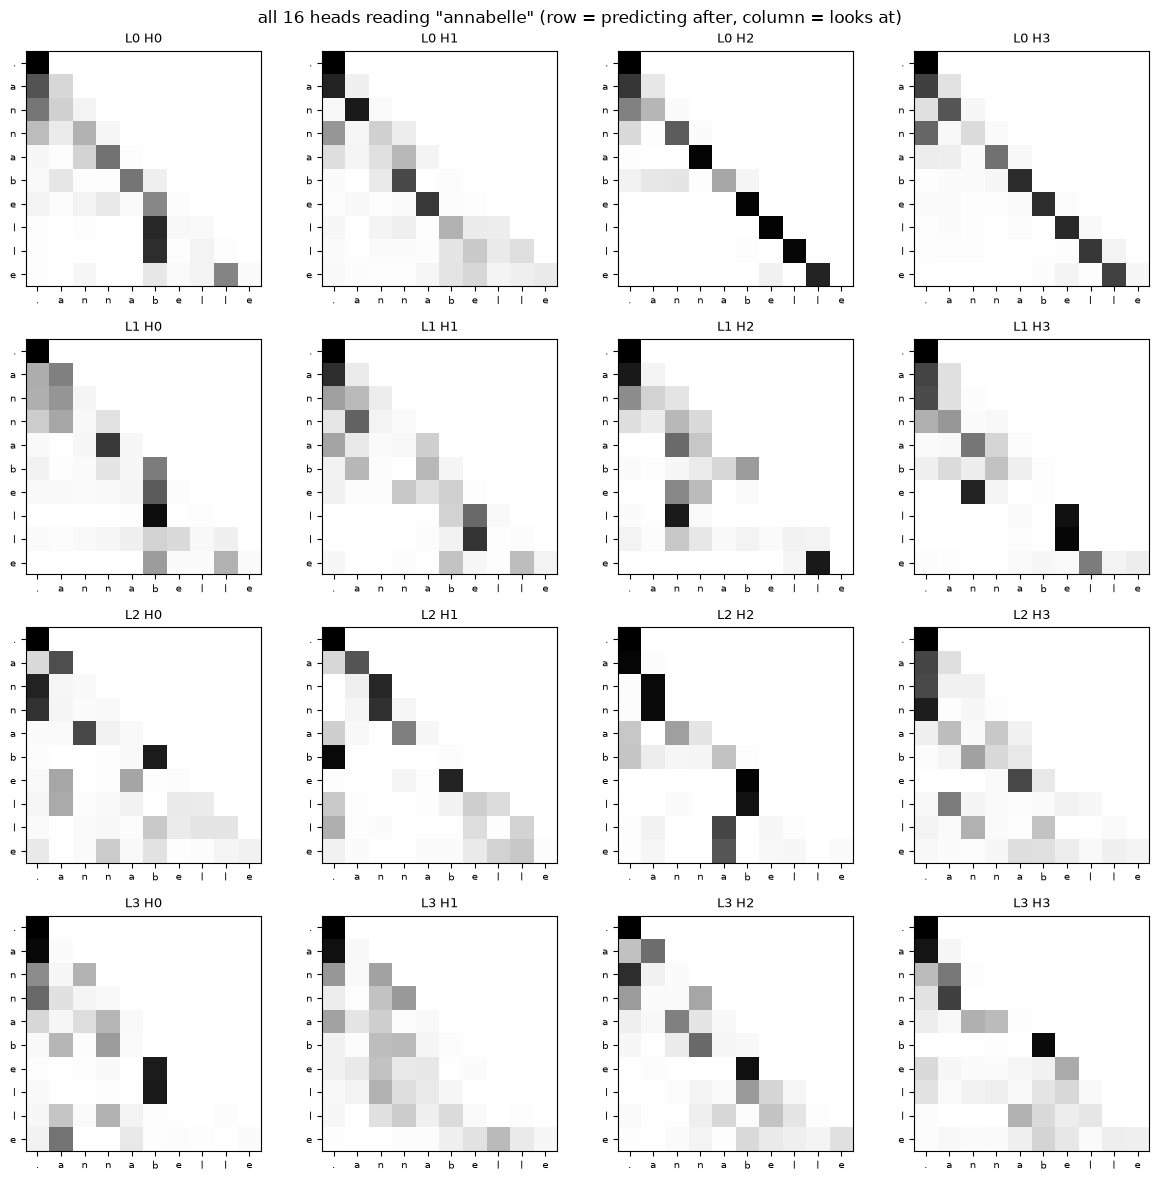

In [2]:
def attention_for(name):
    with torch.no_grad():
        walter(names.encode(name))
    return [b.attn.att[0] for b in walter.blocks]     # per layer: (heads, T, T)

name = 'annabelle'
atts = attention_for(name)
labels = ['.'] + list(name)
fig, axes = plt.subplots(L, H, figsize=(12, 12))
for l in range(L):
    for h in range(H):
        ax = axes[l, h]
        ax.imshow(atts[l][h], cmap='Greys', vmin=0, vmax=1)
        ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=7)
        ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=7)
        ax.set_title(f'L{l} H{h}', fontsize=9)
fig.suptitle(f'all 16 heads reading "{name}" (row = predicting after, column = looks at)')
plt.tight_layout(); plt.show()

Some heads in layer 0 draw a crisp line **just below the diagonal**: at each position they look at the letter immediately before. Further up the stack, heads still often pick one position sharply, but they jump to letters further back rather than the one just before, and a lot of attention lands on column `.`.

But this is one name. Pictures are where hypotheses come from, not where they get proven.

## Tool 2 — Measure: what does each head do *on average*?

For every head, across all 3,203 dev names, we measure how much of its attention goes to:

- the **previous** letter (position `t − 1`)
- the **current** letter itself (position `t`)
- the **start** marker `.` (position 0)

We skip the first two positions, where these categories overlap.

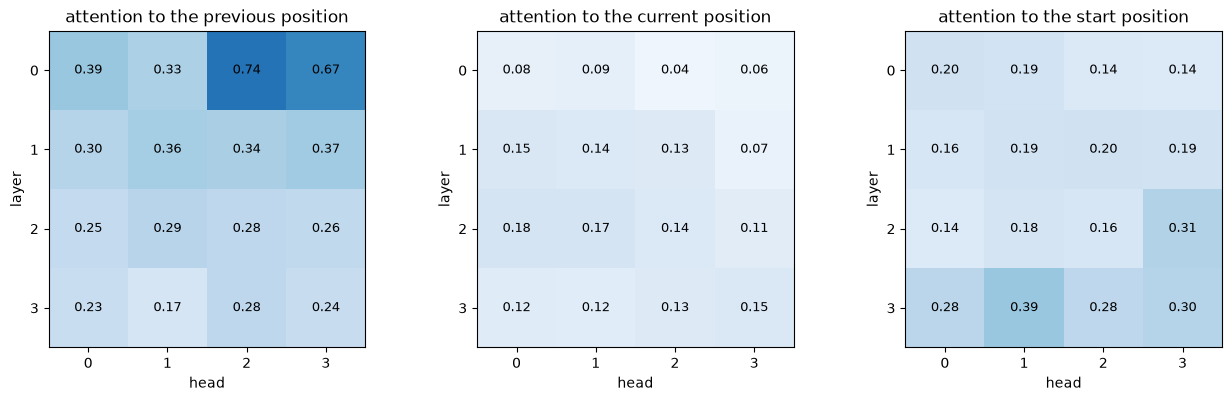

the two strongest previous-letter heads: L0 H2 (74%), L0 H3 (67%)


In [3]:
with torch.no_grad():
    walter(Xdev)
all_att = [b.attn.att for b in walter.blocks]          # per layer: (names, heads, T, T)

T = Xdev.shape[1]
t = torch.arange(2, T)
valid = (Ydev[:, 2:] != -1)                           # real positions only, no padding

scores = {k: torch.zeros(L, H) for k in ['previous', 'current', 'start']}
for l in range(L):
    for h in range(H):
        a = all_att[l][:, h]
        scores['previous'][l, h] = a[:, t, t - 1][valid].mean()
        scores['current'][l, h]  = a[:, t, t][valid].mean()
        scores['start'][l, h]    = a[:, t, 0][valid].mean()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (k, s) in zip(axes, scores.items()):
    im = ax.imshow(s, cmap='Blues', vmin=0, vmax=1)
    for l in range(L):
        for h in range(H):
            ax.text(h, l, f'{s[l, h]:.2f}', ha='center', va='center', fontsize=9)
    ax.set_xticks(range(H)); ax.set_xlabel('head')
    ax.set_yticks(range(L)); ax.set_ylabel('layer')
    ax.set_title(f'attention to the {k} position')
plt.tight_layout(); plt.show()

flat = scores['previous'].flatten()
prev_heads = [(int(i) // H, int(i) % H) for i in flat.argsort(descending=True)[:2]]
print('the two strongest previous-letter heads:', ', '.join(f'L{l} H{h} ({scores["previous"][l, h]:.0%})' for l, h in prev_heads))

Now the picture holds up across thousands of names:

- **Layer 0 contains previous-letter heads.** Two heads put most of their attention on the letter just before. There are 15 earlier positions they could look at, yet they pick one specific one, consistently.
- **Later layers use the start marker more.** Attention must add up to 1, so a head with nothing useful to fetch still has to put its weight somewhere. `.` is always there and carries little information, which makes it a natural place to park, a kind of "no-op" default. Researchers call this an **attention sink**, and large language models do it too.

A previous-letter head is a sensible thing to have. The residual stream at position `t` starts out knowing only the current letter and position (Rung 4). A previous-letter head copies in *the letter before*, so after layer 0 each position knows the last **two** letters. That's a trigram's worth of context, built from attention.

That's a hypothesis about **why** these heads exist. Time to test it.

## Tool 3 — Break: switch heads off

Each head's output is multiplied by `head_mask`, which is normally 1. Setting it to 0 deletes that head's contribution, as if it had never been trained. If dev loss rises a lot, the head was doing important work.

(Zeroing is the crudest form of ablation. It can also confuse the downstream layers, which never saw a head output exactly zero during training. It's a good first pass, not the final word.)

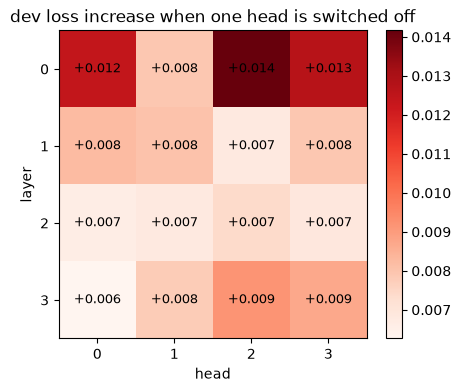

switching off a whole layer of attention:
  layer 0: +0.1774


  layer 1: +0.0423
  layer 2: +0.0321


  layer 3: +0.0385


In [4]:
def ablated_loss(heads):
    for l, h in heads:
        walter.blocks[l].attn.head_mask[h] = 0
    loss = wg.evaluate(walter, Xdev, Ydev)
    for l, h in heads:
        walter.blocks[l].attn.head_mask[h] = 1
    return loss

damage = torch.zeros(L, H)
for l in range(L):
    for h in range(H):
        damage[l, h] = ablated_loss([(l, h)]) - base_loss

plt.figure(figsize=(5, 4))
plt.imshow(damage, cmap='Reds')
for l in range(L):
    for h in range(H):
        plt.text(h, l, f'+{damage[l, h]:.3f}', ha='center', va='center', fontsize=9)
plt.xticks(range(H)); plt.xlabel('head'); plt.yticks(range(L)); plt.ylabel('layer')
plt.title('dev loss increase when one head is switched off')
plt.colorbar(); plt.show()

print('switching off a whole layer of attention:')
for l in range(L):
    print(f'  layer {l}: +{ablated_loss([(l, h) for h in range(H)]) - base_loss:.4f}')

A surprise: **no single head is critical.** Switching off any one head costs only around +0.01. Switching off **all of layer 0's attention** costs far more than the four individual damages added together.

That's **redundancy**. Heads overlap in what they do, so when one goes, others partly cover for it. Let's test that directly on the two previous-letter heads.

In [5]:
a, b = prev_heads
da, db = ablated_loss([a]) - base_loss, ablated_loss([b]) - base_loss
dab = ablated_loss([a, b]) - base_loss
print(f'switch off L{a[0]} H{a[1]} alone : +{da:.4f}')
print(f'switch off L{b[0]} H{b[1]} alone : +{db:.4f}')
print(f'sum of the two         : +{da + db:.4f}')
print(f'switch off both        : +{dab:.4f}   <- {dab / (da + db):.1f}x the sum')

switch off L0 H2 alone : +0.0142
switch off L0 H3 alone : +0.0127
sum of the two         : +0.0269
switch off both        : +0.0584   <- 2.2x the sum


Losing both costs more than twice the two separate losses added up. Each previous-letter head is a **backup** for the other. If you judged heads only by switching them off one at a time, you'd conclude neither matters much, and you'd be wrong. This is one of the classic traps of interpretability. Real circuits in large language models show the same self-repair.

## Putting it together: a testable prediction

If the previous-letter heads really give each position "the letter before", then without them Walter should fail at anything that **depends** on the letter before the current one. Here's a clean test.

**Doubled letters.** Names double letters all the time (`anna`, `bella`, `emmett`) but practically never triple them. So:

- at an `n` that follows an `a` (as in `an`), another `n` is quite possible
- at an `n` that follows another `n` (as in `ann`), another `n` should be **almost impossible**

Telling those apart needs the previous letter, since the current letter is `n` in both cases. So the prediction is: **intact, Walter knows not to triple; with the previous-letter heads off, he should forget.**

In [6]:
cur, prv, y = Xdev[:, 2:], Xdev[:, 1:-1], Ydev[:, 2:]
doubled     = (cur == prv) & (cur != 0) & (y != -1)              # current letter repeats the one before
not_doubled = (cur != prv) & (cur != 0) & (prv != 0) & (y != -1)

def p_repeat(heads_off):
    for l, h in heads_off:
        walter.blocks[l].attn.head_mask[h] = 0
    with torch.no_grad():
        probs = F.softmax(walter(Xdev)[0], dim=-1)[:, 2:]
    for l, h in heads_off:
        walter.blocks[l].attn.head_mask[h] = 1
    p = probs.gather(-1, cur.unsqueeze(-1)).squeeze(-1)          # P(next letter = current letter)
    return p[doubled].mean().item(), p[not_doubled].mean().item()

print(f'in the dev names: {doubled.sum().item()} doubled positions; '
      f'how often the next letter repeats again: {(y[doubled] == cur[doubled]).float().mean():.1%} after a double, '
      f'{(y[not_doubled] == cur[not_doubled]).float().mean():.1%} otherwise\n')
print('Walter\'s probability that the next letter repeats the current one:')
for tag, off in [('intact', []), ('previous-letter heads off', prev_heads)]:
    d, nd = p_repeat(off)
    print(f'  {tag:27s} just doubled: {d:6.1%}    not doubled: {nd:6.1%}')

in the dev names: 727 doubled positions; how often the next letter repeats again: 0.0% after a double, 4.5% otherwise

Walter's probability that the next letter repeats the current one:


  intact                      just doubled:   0.3%    not doubled:   4.7%


  previous-letter heads off   just doubled:   4.9%    not doubled:   4.2%


The prediction holds, and sharply.

- **Intact**, Walter puts almost no probability on a third repeat right after a double, while still allowing a double elsewhere. He has learned the rule "never triple a letter".
- **With the two previous-letter heads off**, his probability of a third repeat after a double jumps up to roughly his ordinary repeat rate. He can no longer tell `ann` from `an`, because the information "the letter before was also `n`" never arrives.

So now we know more than "these heads look at the previous letter". We know what they're *for*: they carry the previous letter into the current position, where later layers use it, among other things to enforce the no-triple rule. That's a small, complete, causally tested mechanism, which is what interpretability calls a **circuit**.

## Tool 4 — Read the stream: the logit lens

The final step of the forward pass turns the residual stream into predictions (`ln_f` then `lm_head`). Nothing stops us from applying that same step **early**, to the stream after just 0, 1, 2 or 3 blocks, and asking: *if Walter had to answer now, what would he say?*

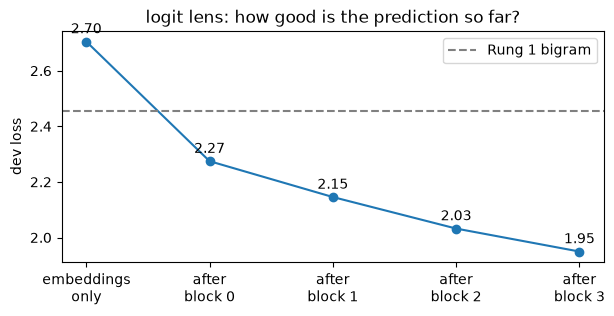

In [7]:
with torch.no_grad():
    _, _, residuals = walter(Xdev, return_residuals=True)
    lens = [F.cross_entropy(walter.lm_head(walter.ln_f(r)).view(-1, 27), Ydev.view(-1), ignore_index=-1).item()
            for r in residuals]

labels = ['embeddings\nonly'] + [f'after\nblock {i}' for i in range(L)]
plt.figure(figsize=(7, 3))
plt.plot(labels, lens, 'o-')
for i, v in enumerate(lens):
    plt.text(i, v + 0.03, f'{v:.2f}', ha='center')
plt.axhline(2.4533, color='gray', ls='--', label='Rung 1 bigram')
plt.ylabel('dev loss'); plt.title('logit lens: how good is the prediction so far?'); plt.legend()
plt.show()

Every block makes the prediction better. The biggest jump comes from block 0, where the previous-letter heads live, and each later block refines a little more.

The "embeddings only" point is *worse* than the bigram. That doesn't mean Walter knows less than a bigram at the start. The final readout (`ln_f`, `lm_head`) was trained to read the stream at the **top** of the stack, so reading it at the bottom is like reading a draft with the final edition's glasses. The logit lens is a useful approximation, not an exact measurement.

Here is the same thing for a single prediction: Walter has read `.anna` and must predict what comes next.

In [8]:
prefix = 'anna'
with torch.no_grad():
    _, _, res = walter(names.encode(prefix), return_residuals=True)
for i, r in enumerate(res):
    probs = F.softmax(walter.lm_head(walter.ln_f(r[0, -1])), dim=-1)
    top = probs.topk(5)
    stage = 'embeddings only' if i == 0 else f'after block {i - 1}'
    print(f'{stage:16s}', '  '.join(f"'{names.itos[j.item()]}' {p:.2f}" for p, j in zip(top.values, top.indices)))

embeddings only  '.' 0.30  'n' 0.13  'l' 0.08  'm' 0.07  'i' 0.07
after block 0    '.' 0.20  't' 0.14  'h' 0.10  's' 0.09  'y' 0.07
after block 1    'l' 0.16  '.' 0.14  'h' 0.13  'v' 0.09  's' 0.09
after block 2    'l' 0.16  'h' 0.14  '.' 0.11  's' 0.11  'v' 0.06
after block 3    'l' 0.43  's' 0.07  '.' 0.07  'b' 0.06  'h' 0.05


Watch the guess get sharper. Early on, Walter has little more than "the current letter is `a`" to go on. As blocks add context (the previous letters, how long the name is so far), he settles on the continuations that real names starting `anna` actually take, like ending the name or continuing with letters like `l` or `b`.

## What we found, and what we didn't

**Found:**
1. **Previous-letter heads** in layer 0, measured over thousands of names and not just one picture.
2. **Attention sinks**: later heads park unneeded attention on the `.` start marker.
3. **Redundancy**: single-head ablations barely register, but pairs and whole layers do. The two previous-letter heads back each other up.
4. **A tested circuit**: the previous-letter heads carry the letter before into each position, and without them Walter forgets that letters don't triple.
5. **Gradual refinement**: each block improves the prediction, with the biggest step in block 0.

**Not yet explained:** most of what the MLPs do; what the heads in layers 1–3 compute, many of which jump sharply to specific earlier letters; how Walter tracks name length to decide when to stop. As Rung 3's embeddings already hinted, the network doesn't owe us neat, human-shaped features. A single neuron or direction often mixes several unrelated jobs (**superposition**). Untangling that is a large part of modern interpretability research.

And the honest caveats: this is one small model, trained once, on one dataset. Zero-ablation is a blunt tool. The categories we measured (previous, current, start) are ones *we* chose, so a head doing something we didn't think to measure gets no label from us, however clear its job is.

## The whole climb

| Rung | Walter | dev loss |
|---|---|---|
| 1 | counts letter pairs | 2.45 |
| 2 | *learns* the same table by gradient descent | 2.45 |
| 3 | remembers 3 letters with embeddings + an MLP | 2.11 |
| 4 | attends over the whole name | 2.15 |
| 5 | becomes a 4-layer GPT | 1.95 |
| 6 | is opened up: previous-letter heads, attention sinks, redundancy, a tested circuit | — |

Text became numbers, numbers became probabilities, probabilities became a loss, the loss taught a network, and the network turned out to contain small machines we could find, break and understand.

## Your turn
- Find which head (or pair of heads) matters most for predicting the **end** of a name. (Hint: restrict the loss to positions whose target is `.`.)
- Replace zero-ablation with **mean-ablation**: set a head's output to its average output instead of 0. Do the damage numbers change?
- Repeat the doubled-letter test with each previous-letter head switched off **alone**. Does either one on its own break the rule?
- Retrain Walter with `n_layer=1` (Rung 5) and look again. Do previous-letter heads still appear? What happens to redundancy?

**Where this leads:** the same tools (attention patterns, ablation, logit lens, circuit hypotheses tested by intervention) are what researchers use on large language models. Good next reading: Anthropic's *A Mathematical Framework for Transformer Circuits* and *In-context Learning and Induction Heads*, and Neel Nanda's TransformerLens tutorials. An **induction head**, which finds the previous time the current token appeared and copies what came next, is built from a previous-token head like the one we found here, plus one more head in a later layer.